In [2]:
import pymupdf4llm
raw_md_text = pymupdf4llm.to_markdown("pdf-docs.pdf")

Consider using the pymupdf_layout package for a greatly improved page layout analysis.


In [3]:
import re


def process_text_to_markdown(text: str) -> str:
    """
    Convert raw text / markdown to clean markdown for RAG
    """

    # 1️⃣ Remove markdown links but keep the text
    # [text](url) -> text
    text = re.sub(r'\[([^\]]+)\]\(([^)]+)\)', r'\1', text)

    # 2️⃣ Remove raw URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3️⃣ Remove navigation / junk words
    junk_patterns = [
        r'Log in',
        r'Get started',
        r'Sign up',
        r'More information',
        r'Found an Error\?',
        r'English|Español|Português|Deutsch|Français',
    ]

    for pattern in junk_patterns:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)

    # 4️⃣ Normalize whitespace
    text = re.sub(r'[ \t]+', ' ', text)

    # remove excessive newlines
    text = re.sub(r'\n{3,}', '\n\n', text)

    # 5️⃣ Preserve headings (ensure spacing before headings)
    text = re.sub(r'\n(#)', r'\n\n\1', text)

    # strip start/end spaces
    text = text.strip()

    return text

In [4]:
clean_md_text = process_text_to_markdown(raw_md_text)

In [5]:
print(len(raw_md_text), len(clean_md_text))

21872 21546


In [6]:
# configuration parameters

chunk_size = 500
chunk_overlap = 75

ret_limit = 3

tavily_limit = 1 

UPPER_TH = 0.7
LOWER_TH = 0.3

In [7]:


from langchain_text_splitters import RecursiveCharacterTextSplitter



splitter = RecursiveCharacterTextSplitter(
    chunk_size = chunk_size,
    chunk_overlap= chunk_overlap
)

docs = splitter.split_text(clean_md_text)

from sentence_transformers import SentenceTransformer

emd_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

from qdrant_client import QdrantClient

client = QdrantClient(":memory:")

from qdrant_client.models import VectorParams, Distance

client.create_collection(
    collection_name = "documents",
    vectors_config = VectorParams(
        size = 384,
        distance = Distance.COSINE
    )
)

from qdrant_client.models import PointStruct

emd_docs = emd_model.encode(docs)

points = [
    PointStruct(
        id=i,
        vector=emd_docs[i],
        payload={"text": docs[i]}
    )
    for i in range(len(docs))
]

client.upsert(
    collection_name="documents",
    points=points
)



d:\1.DS projects\5-GenAI\10_crag\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
d:\1.DS projects\5-GenAI\10_crag\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 6141a795-6f52-45e7-807b-b79c71c5d9fa)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/./modules.json
Retrying

UpdateResult(operation_id=0, status=<UpdateStatus.COMPLETED: 'completed'>)

In [8]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import re
import os

from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv


from langchain_community.tools.tavily_search import TavilySearchResults

load_dotenv()

True

In [9]:
# ---- YOUR MODEL (converted to LangChain wrapper) ----
from  langchain_groq  import ChatGroq
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0.7
)

In [10]:
# -----------------------------
# State
# -----------------------------
class State(TypedDict):
    question: str

    docs: List[Document]
    good_docs: List[Document]

    verdict: str
    reason: str

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    web_query: str
    
    web_docs: List[Document]

    answer: str

In [11]:
# -----------------------------
# Retrieve
# -----------------------------
def retrieve_node(state: State) -> State:
    q = state["question"]
    query_vector = emd_model.encode_query(q)
    results = client.query_points(
    collection_name="documents",
    query=query_vector,
    limit=ret_limit
)
    return {"docs": [Document(page_content=p.payload["text"], metadata={"id": p.id}) for p in results.points]}


In [12]:
# -----------------------------
# Score-based doc evaluator
# -----------------------------
class DocEvalScore(BaseModel):
    score: float
    reason: str


doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)


def eval_each_doc_node(state: State) -> State:
    q = state["question"]
    scores: List[float] = []
    good: List[Document] = []

    for d in state["docs"]:
        out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})
        scores.append(out.score)

        # Keep any doc above LOWER_TH as "weakly relevant"
        if out.score > LOWER_TH:
            good.append(d)

    # CORRECT: at least one doc > UPPER_TH
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    # INCORRECT: all docs < LOWER_TH
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}.",
        }

    # AMBIGUOUS: otherwise
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}.",
    }


In [13]:
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


# -----------------------------
# FILTER (LLM judge)
# -----------------------------
# from pydantic import field_validator

class KeepOrDrop(BaseModel):
    keep: bool = Field(description="Must be a boolean value (true or false), not a string.")
    
    # @field_validator('keep', mode='before')
    # @classmethod
    # def convert_keep(cls, v):
    #     if isinstance(v, str):
    #         return v.lower() in ('true', '1', 'yes')
    #     return bool(v)


filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Set `keep` to boolean true (not a string) only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)


# -----------------------------
# Knowledge refinement
# (CORRECT => internal only)
# (INCORRECT => web only)
# (AMBIGUOUS => internal + web)
# -----------------------------
def refine(state: State) -> State:
    q = state["question"]

    if state.get("verdict") == "CORRECT":
        docs_to_use = state["good_docs"]
    elif state.get("verdict") == "INCORRECT":
        docs_to_use = state["web_docs"]
    else:  # AMBIGUOUS
        docs_to_use = state["good_docs"] + state["web_docs"]

    context = "\n\n".join(d.page_content for d in docs_to_use).strip()

    strips = decompose_to_sentences(context)

    kept: List[str] = []
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }

In [14]:
# -----------------------------
# Query rewrite for web search
# -----------------------------
class WebQuery(BaseModel):
    query: str


rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)


def rewrite_query_node(state: State) -> State:
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.query}


# -----------------------------
# Web search node: uses web_query
# -----------------------------
tavily = TavilySearchResults(max_results=tavily_limit)


def web_search_node(state: State) -> State:
    q = state.get("web_query") or state["question"]
    results = tavily.invoke({"query": q})

    web_docs: List[Document] = []
    for r in results or []:
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"
        web_docs.append(Document(page_content=text, metadata={"url": url, "title": title}))

    return {"web_docs": web_docs}


C:\Users\karti\AppData\Local\Temp\ipykernel_14512\4258392305.py:34: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=tavily_limit)


In [15]:
# -----------------------------
# Generate
# -----------------------------
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'",
        ),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)


def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "context": state["refined_context"]})
    return {"answer": out.content}

In [16]:
# -----------------------------
# Routing
# CORRECT => refine
# INCORRECT / AMBIGUOUS => rewrite -> web_search -> refine -> generate
# -----------------------------
def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    else:
        return "rewrite_query"


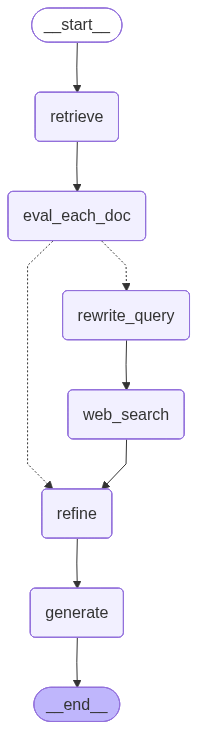

In [17]:
# -----------------------------
# Build graph
# -----------------------------
g = StateGraph(State)

g.add_node("retrieve", retrieve_node)
g.add_node("eval_each_doc", eval_each_doc_node)

g.add_node("rewrite_query", rewrite_query_node)
g.add_node("web_search", web_search_node)

g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {
        "refine": "refine",
        "rewrite_query": "rewrite_query",
    },
)

# non-correct path
g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "refine")

# correct path already goes to refine
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app


In [21]:
# -----------------------------
# Run example
# -----------------------------
res = app.invoke(
    {
        "question": " Safety Rules (Domain Locking) What This Means:",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_query": "",
        "web_docs": [],
        "answer": "",
        "e": ""
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("WEB_QUERY:", res["web_query"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: CORRECT
REASON: At least one retrieved chunk scored > 0.7.
WEB_QUERY: 

OUTPUT:
 Domain Locking refers to safety rules where documents are uploaded, processed, and then deleted after 24 hours, with only final registration status and no personal documents being kept, and those are encrypted.


In [19]:
res['web_docs']

[]

In [24]:
import json

with open("evaluation_dataset.json", "r") as f:
    dataset = json.load(f)

print("Total questions:", len(dataset))

Total questions: 8


In [26]:
data = []

for item in dataset:

    question = item["question"]
    gt = item["ground_truth"]

    res = app.invoke(
        {
            "question": question,
            "docs": [],
            "good_docs": [],
            "verdict": "",
            "reason": "",
            "strips": [],
            "kept_strips": [],
            "refined_context": "",
            "web_query": "",
            "web_docs": [],
            "answer": "",
            "e": ""
        }
    )

    answer = res["answer"]

    # use context returned from pipeline
    context = res["refined_context"]

    data.append({
        "question": question,
        "answer": answer,
        "contexts": [context],
        "ground_truth": gt
    })

In [27]:
from datasets import Dataset

rag_dataset = Dataset.from_list(data)

In [28]:
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall
)

C:\Users\karti\AppData\Local\Temp\ipykernel_14512\1080591546.py:1: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
C:\Users\karti\AppData\Local\Temp\ipykernel_14512\1080591546.py:1: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
C:\Users\karti\AppData\Local\Temp\ipykernel_14512\1080591546.py:1: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import (
C:\Users\karti\AppData\Local\Temp\ipykernel_14

In [30]:
from ragas import evaluate

results = evaluate(
    rag_dataset,
    metrics=[
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall
    ],
    llm=llm,
    embeddings=emd_model
)

print(results)

Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Exception raised in Job[1]: AttributeError('SentenceTransformer' object has no attribute 'embed_query')
Evaluating:   3%|▎         | 1/32 [00:04<02:17,  4.44s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Exception raised in Job[13]: AttributeError('SentenceTransformer' object has no attribute 'embed_query')
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Exception raised in Job[5]: AttributeError('SentenceTransformer' object has no attribute 'embed_query')
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Exception raised in Job[9]: AttributeError('SentenceTransformer' object has no attribute 'embed_query')
Evaluating: 100%|██████████| 32/32 [04:41<00:00,  8.79s/it]


{'faithfulness': 1.0000, 'answer_relevancy': nan, 'context_precision': 0.5000, 'context_recall': 0.5000}
